<a href="https://colab.research.google.com/github/farinaz-hatami/Module-3-Assignments/blob/main/OMDS_MODEB2_Week8_HATAMI_FARINAZ.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 8 - Multivariate Analysis

## Please run the cells of the notebook as you get to them while reading

In [1]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import seaborn as sns
from sklearn import decomposition
from sklearn import linear_model
from sklearn import metrics

# 1. Lesson: Multivariate graphs

In this lesson, we'll consider some multivariate plots: heatmaps and bubble plots.  We'll also consider principal component analysis and multiple regression.

### Heatmaps

In this plot, we use a heatmap to count the total traffic tickets given to citizens.  A heatmap requires the x and y axes to be categorical, while the color involves a third, numerical variable.  In this example, each row of the DataFrame represents a traffic ticket given to one person in a particular city and year.  The data are given as three columns (city, year, and ticket), so we must use a pivot_table to transform it into a two-dimensional grid.  The cmap is set to "Blues" in the first example, meaning that the heatmap uses only blue as its color.  However, we could also use a multicolor map like "viridis" in the second example.  I personally think "Blues" is easier to read - what do you think?  Here is a reference guide to the color maps:

https://matplotlib.org/stable/gallery/color/colormap_reference.html

In [2]:
np.random.seed(0)
num_samples = 100
city_series = np.random.choice(["New York", "Boston", "Atlanta", "Washington, D. C."], size = num_samples)
year_series = np.random.choice([2018, 2019, 2020], size = num_samples)
ticket_series = np.random.randint(50, 150, size = num_samples) # Traffic tickets can be from $50 to $150
df = pd.DataFrame({"city": city_series, "year": year_series, "ticket": ticket_series})
pivot = df.pivot_table(index = ["city"], columns = ["year"], values = "ticket", aggfunc = "sum")

In [3]:
df.iloc[0:5] # first five rows of a long DataFrame

,city,year,ticket
0,New York,2019,79
1,"Washington, D. C.",2020,71
2,Boston,2018,75
3,New York,2018,130
4,"Washington, D. C.",2020,110


In [4]:
pivot # 2 by 2 grid showing total ticket amounts

year,2018,2019,2020
city,,,
Atlanta,742,440,538
Boston,775,628,922
New York,1122,841,596
"Washington, D. C.",1258,451,1385


Text(0.5, 1.0, 'Total traffic tickets by city and year')

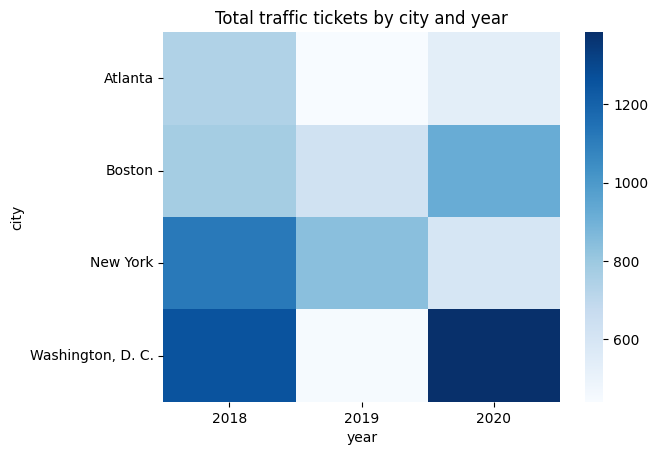

In [5]:
ax = sns.heatmap(pivot, cmap = "Blues")
ax.set_title("Total traffic tickets by city and year")

Text(0.5, 1.0, 'Average traffic ticket value by city and year')

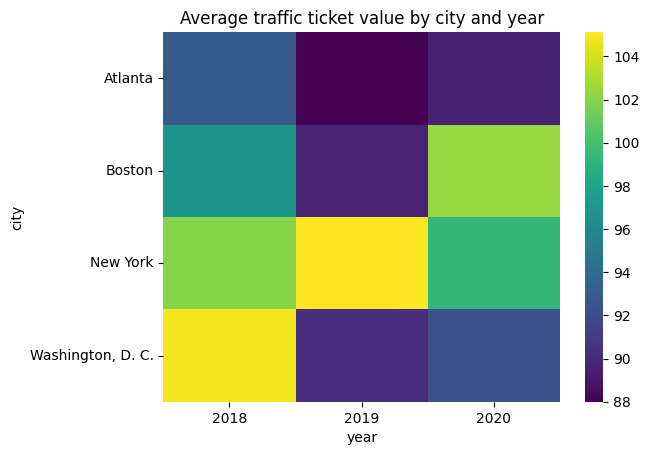

In [6]:
pivot2 = df.pivot_table(index = ["city"], columns = ["year"], values = "ticket", aggfunc = "mean") # note mean, not sum this time
ax2 = sns.heatmap(pivot2, cmap = "viridis") # do you think this is a better or worse scale than Blues?
ax2.set_title("Average traffic ticket value by city and year")

### Bubble plots

A bubble plot is just a scatter plot, but with the dot size representing a third variable.  Here, each data point shows a tree (I mean the kind of tree that is a plant and grows in the ground, not a decision tree), with its height, width of branches, and root depth.  The bubble size in the bubble plot represents the root depth, while the other variables are shown on the x and y axes.  From this plot, we can see that the root depth is strongly correlated with both the width of branches and the tree height.

Text(0, 0.5, 'width of branches')

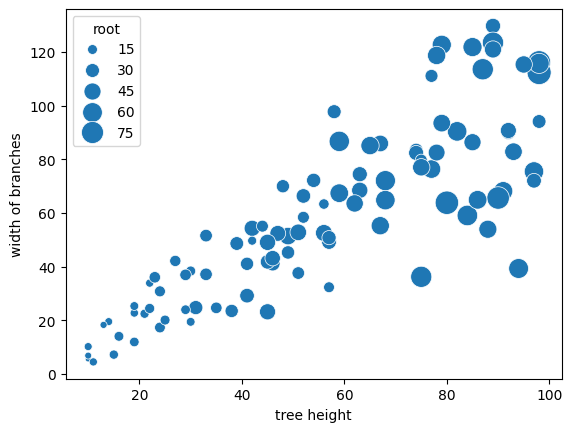

In [7]:
np.random.seed(0)
num_samples = 100
height_series = np.random.randint(10, 100, size = num_samples) # tree height
width_series = height_series * np.maximum(np.random.normal(scale = 0.3, loc = 1, size = num_samples), 0.25) # strongly related to height
root_series = height_series * np.maximum(np.random.normal(scale = 0.2, loc = 0.7, size = num_samples), 0.3) # strongly related to height
df2 = pd.DataFrame({'height': height_series, 'width': width_series, 'root': root_series})
minroot = root_series.min()
maxroot = root_series.max()
maxbubble = 300
ax = sns.scatterplot(data = df2, x = "height", y = "width", size = "root", sizes = (minroot / maxroot * maxbubble, maxbubble))
ax.set_xlabel("tree height")
ax.set_ylabel("width of branches")

### Principal Component Analysis

Principal Component Analysis can be thought of as a way to use one (or a few) linear combinations of the coordinates in order to explain all of the coordinates.  It is most useful when there are strong correlations between some or all of the coordinates.  Principal Component Analysis can show us which linear combinations are most (and least) useful for explaining the data.

With the trees data, the three values (height, width, and root) are highly correlated.  For this reason, Principal Component Analysis shows that most of the variance can be explained by a single value which is a linear combination of height, width, and root.  What this means is that if the first components_ vector in the code below (the "first principal component") is \[a, b, c\], for some specific numbers a, b, and c, then the value v = a * (height - mu_h) + b * (width - mu_w) + c * (root - mu_r), where the mu's are the means, is highly informative about the values of height, width, and root.  In this case, because height, width, and root are so highly correlated, we can almost assume that all of the data is located along an axis defined by the vector \[a, b, c\].  The point v * \[a, b, c\] + (mean vector) = (a * (height - mu_h) + b * (width - mu_w) + c * (root - mu_r)) * \[a, b, c\] + (mean vector) is therefore approximately equal to the data point (height, width, root) in question.  The mean vector is \[mu_h, mu_w, mu_r\].  Importantly, there is still variance unexplained by this one value - just knowing v * \[a, b, c\] does not tell you the height, width, and root with 100% accuracy.  If the second principal component is \[d, e, f\], then we could approximate the tree vector even more accurately as: (height, width, root) = (a * (height - mu_h) + b * (width - mu_w) + c * (root - mu_r)) * \[a, b, c\] + (d * (height - mu_h) + e * (width - mu_w) + f * (root - mu_r)) * \[d, e, f\] + (mean vector).

The printing of "components_", below, shows the first principal component \[a, b, c\].  If you draw a vector in the direction shown, you will be heading in the direction where the values height, width, and root change most rapidly.  A later computation shows all three principal component vectors.

**Optional exercise for the reader:** show that if all three principal components are included, then equality is exact.  This is going to be true simply because the principal components are orthonormal: the projections onto a complete set of orthonormal vectors always add up to the original vector.

(height, width, root) = (a * (height - mu_h) + b * (width - mu_w) + c * (root - mu_r)) * \[a, b, c\] + (d * (height - mu_h) + e * (width - mu_w) + f * (root - mu_r)) * \[d, e, f\] + (g * (height - mu_h) + h * (width - mu_w) + i * (root - mu_r)) * \[g, h, i\] + \[mu_h, mu_w, mu_r\].

For this proof, we must use the fact that the principal component vectors are orthonormal.  That is, any pair of them are orthogonal, even with a transpose (ad + be + cf = 0, ag + bh + ci = 0, dg + eh + fi = 0, ab + de + gh = 0, ac + df + gi = 0, bc + ef + hi = 0) and any one of them is a unit vector, even with a transpose (a^2 + b^c + c^2 = 1, d^2 + e^2 + f^2 = 1, g^2 + h^2 + i^2 = 1, a^2 + d^2 + g^2 = 1, b^2 + e^2 + h^2 = 1, c^2 + f^2 + i^2 = 1).  If you write out the equation above as a single vector, then apply the orthonormality rules, you should be able to prove equality.

In [8]:
pca = decomposition.PCA(n_components = 1)
pca.fit(df2)
print(f"The first principal component explains {pca.explained_variance_ratio_[0]} of the variance")
print(f"The components_ vector is [a, b, c] = {pca.components_}")
mu_h, mu_w, mu_r = df2.mean().values
print(f"(height, width, root) is approximately equal to ({pca.components_[0][0]:.2} * (height - {mu_h:.2}) + {pca.components_[0][1]:.2} * (width - {mu_w:.2}) + {pca.components_[0][2]:.2} * (root - {mu_r:.2})) * ({pca.components_[0][0]:.2}, {pca.components_[0][1]:.2}, {pca.components_[0][2]:.2}) + ({mu_h:.2}, {mu_w:.2}, {mu_r:.2})")
print("Examples: (estimating the the vector equals its projection onto the first principal component)")
df_example = df2.copy()
df_example["v"] = pca.components_[0][0] * (df2["height"] - mu_h) + pca.components_[0][1] * (df2["width"] - mu_w) + pca.components_[0][2] * (df2["root"] - mu_r)
df_example["height_est"] = df_example["v"] * pca.components_[0][0] + mu_h
df_example["width_est"] = df_example["v"] * pca.components_[0][1] + mu_w
df_example["root_est"] = df_example["v"] * pca.components_[0][2] + mu_r
print(df_example.iloc[0:5])
print("Means:")
print(f"mu_h = {mu_h:.3}", f"mu_w = {mu_w:.3}", f"mu_r = {mu_r:.3}")

The first principal component explains 0.8686108480944689 of the variance
The components_ vector is [a, b, c] = [[0.59031629 0.71908728 0.36666083]]
(height, width, root) is approximately equal to (0.59 * (height - 5.6e+01) + 0.72 * (width - 5.9e+01) + 0.37 * (root - 3.6e+01)) * (0.59, 0.72, 0.37) + (5.6e+01, 5.9e+01, 3.6e+01)
Examples: (estimating the the vector equals its projection onto the first principal component)
   height       width       root          v  height_est  width_est   root_est
0      54   72.139334  31.517932   6.287751   60.001762  63.563941  38.673095
1      57   49.169527  33.768693  -7.633330   51.783921  53.553468  33.568780
2      74   83.443733  28.770850  25.215680   71.175227  77.174773  45.613225
3      77   76.353866  53.061241  30.794730   74.468631  81.186597  47.658844
4      77  111.095365  26.006307  45.856916   83.360084  92.017624  53.181557
Means:
mu_h = 56.3 mu_w = 59.0 mu_r = 36.4


If we were to choose a second or third component to preserve, that values below show that each would explain a small, additional amount of the variance.  This means that with this particular dataset, we should likely do PCA using only one component and not two.  If the components' explained variances were closer in magnitude to each other, we might have to include two or even all three values to explain the data.

In [9]:
pca3 = decomposition.PCA(n_components = 3)
pca3.fit(df2)
print(pca3.explained_variance_ratio_)
print(pca3.components_)

[0.86861085 0.09414617 0.03724298]
[[ 0.59031629  0.71908728  0.36666083]
 [ 0.32633701 -0.62809127  0.70640322]
 [ 0.73826204 -0.29734633 -0.6054373 ]]


The principal component vectors shown are orthogonal to each other (their dot product is basically zero).  Here, we check that using the first two vectors.

In [10]:
print(np.array(pca3.components_[0]).dot(np.array(pca3.components_[1])))

-1.6653345369377348e-16


We can use the projection onto the first principal component as if it were a new feature.  For instance, we could plot a histogram of the data against the magnitude of the projection onto the first principal component.  In fact, for some purposes, this magnitude (which we have called v) might make a better feature for data analysis than either height, width, or root.  We must subtract off the mean before the dot product; the understanding is that this represents the component of the data relative to the mean.

<Axes: >

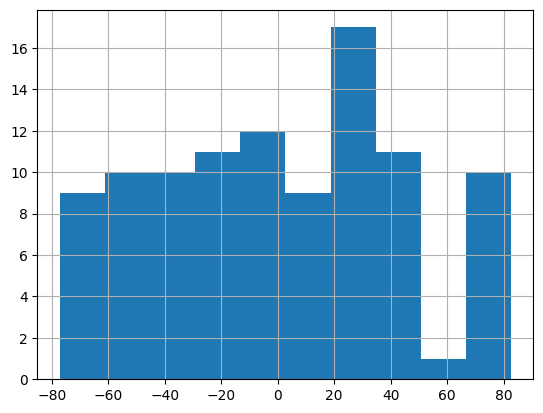

In [11]:
((df2 - df2.mean()).dot(np.array(pca.components_[0]))).hist()

In [ ]:
# Showing that this is the same as the value we've called "v"
(df_example["v"] - (df2 - df2.mean()).dot(np.array(pca.components_[0]))).max()

1.4210854715202004e-14

### Linear Regression

Now let's run a linear regression model to predict the root from the height and width, as well as predicting the third principal component from the first and second.  Which is easier to predict?

### Predicting the root from the height and width

In [12]:
linreg = linear_model.LinearRegression()
linreg.fit(df2[['height', 'width']], df2['root'])
preds = linreg.predict(df2[['height', 'width']])
metrics.mean_squared_error(preds, df2['root']) # Mean squared error as a metric

138.22487356329611

In [13]:
np.corrcoef(preds, df2['root']) # Correlation coefficient as a metric

array([[1.        , 0.79468295],
       [0.79468295, 1.        ]])

### Predicting the third principal component from the first and second

In [14]:
first_principal_component_score = (df2 - df2.mean()).dot(np.array(pca3.components_[0]))
second_principal_component_score = (df2 - df2.mean()).dot(np.array(pca3.components_[1]))
third_principal_component_score = (df2 - df2.mean()).dot(np.array(pca3.components_[2]))

In [15]:
linreg_first = linear_model.LinearRegression()
pc_X = np.array([first_principal_component_score, second_principal_component_score]).T
linreg_first.fit(pc_X, third_principal_component_score)
preds = linreg_first.predict(pc_X)
metrics.mean_squared_error(preds, third_principal_component_score) # The mean squared error is a bit smaller here.

78.74928905273173

In [16]:
np.corrcoef(preds, third_principal_component_score) # More importantly, the correlation is basically zero

array([[1.00000000e+00, 1.55375616e-14],
       [1.55375616e-14, 1.00000000e+00]])

Here, we see that the projections of the first two principal components have no ability to predict the projection of the third, when measured by correlation.  This is a special property of principal components.  It is intended to ensure that the each component gives new information not present in the previous components.

The mean_squared_error is misleading - it makes it look like the error is less for the second computation than the first; but the correlation coefficient is giving more useful information here.  We cannot compare the mean squared error for two totally different computations, because mean squared error is highly dependent on the magnitudes of the values in question!

# 2. Weekly graph question

The tree data above can be graphed via either a pairplot or a bubble plot.  What are the advantages and disadvantages of each?

Text(0, 0.5, 'width of branches')

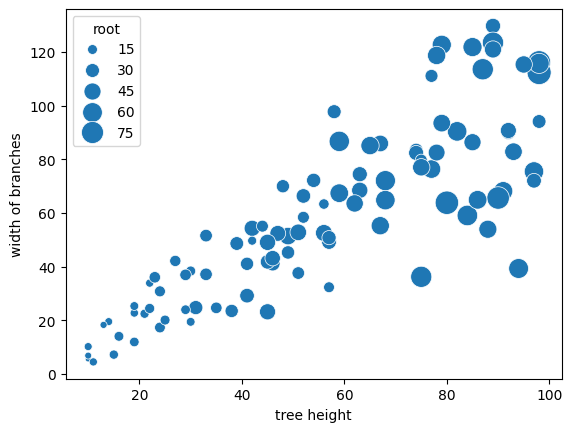

In [17]:
ax = sns.scatterplot(data = df2, x = "height", y = "width", size = "root", sizes = (minroot / maxroot * maxbubble, maxbubble))
ax.set_xlabel("tree height")
ax.set_ylabel("width of branches")

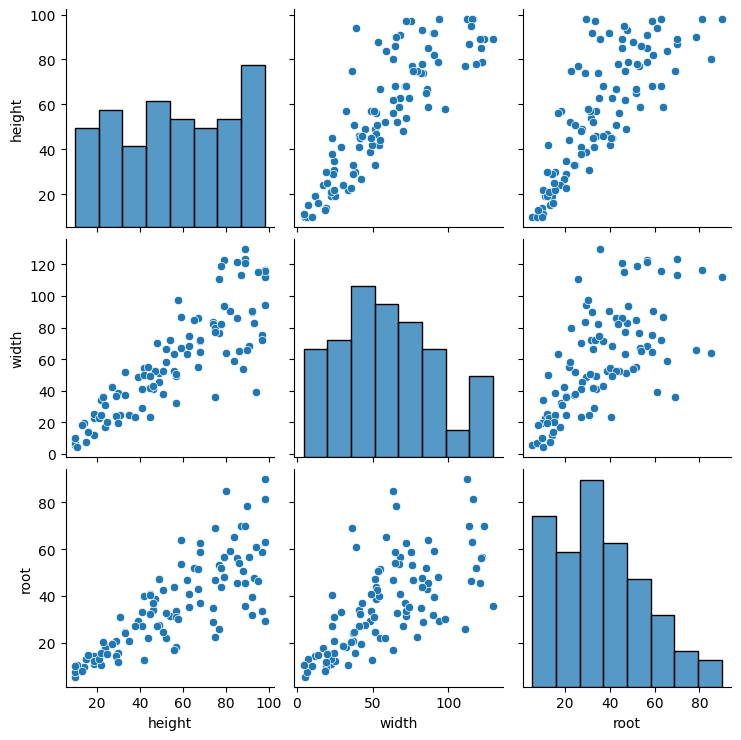

In [18]:
sns.pairplot(df2)

# 3. Homework - Grocery Store Correlation

In a particular state, the price of milk is highly correlated with the price of cheese.  Neither is correlated with the price of bread.

In [36]:
num_points = 1000
np.random.seed(0)
milk_series = np.maximum(np.random.normal(scale = 0.5, loc = 2.00, size = num_points), 1)
cheese_series = milk_series * np.maximum(np.random.normal(scale = 0.1, loc = 1.00, size = num_points), 0.5)
bread_series = np.maximum(np.random.normal(scale = 1.0, loc = 3.00, size = num_points), 1)
df3 = pd.DataFrame({"milk": milk_series, "cheese": cheese_series, "bread": bread_series})

In [37]:
df3.head()

,milk,cheese,bread
0,2.882026,3.042256,1.467079
1,2.200079,2.396430,1.288030
2,2.489369,2.384239,3.046135
3,3.120447,3.153122,2.041626
4,2.933779,3.000685,2.919188


### Heatmap

Draw a heatmap where the x-axis category is a discretized version of the milk price and the y-axis category is a discretized version of the cheese price.  That is, you can choose "low", "medium", and "high" for the milk price, or, if you prefer, you can choose 1, 2, 3, 4, and 5 for the five quintiles.  (The first quintile should include the bottom fifth of the data, the second quintile contains the next fifth, and so on).

Try Googling "how do I change numerical to categorical data" to get advice on this.

Text(0.5, 1.0, 'Bread Price vs Milk and Cheese Quintiles')

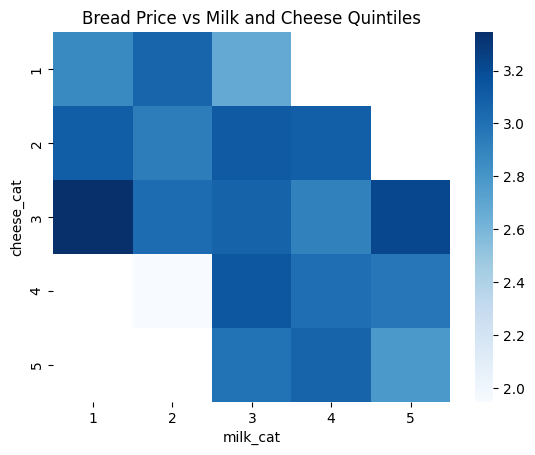

In [23]:
#Convert numerical values to categories
df3["milk_cat"] = pd.qcut(df3["milk"], 5, labels=[1,2,3,4,5])
df3["cheese_cat"] = pd.qcut(df3["cheese"], 5, labels=[1,2,3,4,5])

# Create pivot table            #Creates a 2D grid where:  Rows = cheese quintiles
pivot = df3.pivot_table(                                  # Columns = milk quintiles
    index="cheese_cat",                                   #Values = average bread price in that combination
    columns="milk_cat",
    values="bread",
    aggfunc="mean",
    observed=False
)

# Plot heatmap
ax = sns.heatmap(pivot, cmap="Blues")
ax.set_title("Bread Price vs Milk and Cheese Quintiles")

# * My Interpretation:

The heatmap shows milk price quintiles on the x-axis and cheese price quintiles on the y-axis. Because milk and cheese prices are highly correlated, higher milk categories tend to align with higher cheese categories. Bread prices appear random because bread is not correlated with the other two variables.

### Bubble plot

Try all three possible bubble plots: one where the size of the dot is determined by the milk price, one where it's the cheese price, and one where it's the bread price.  Which of these plots is / are the most informative and useful?

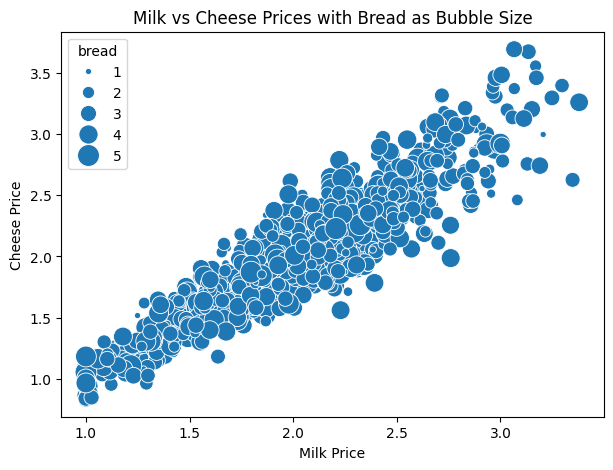

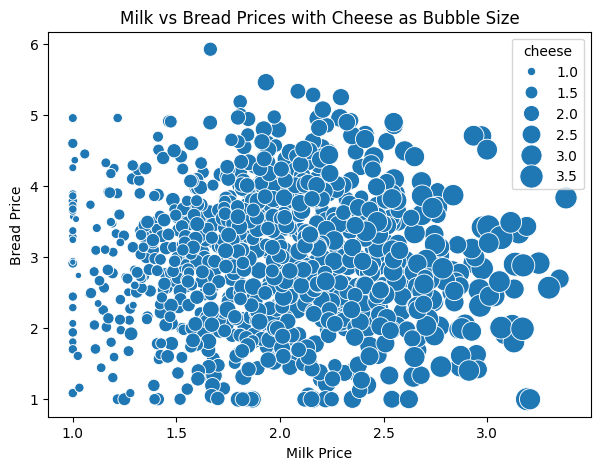

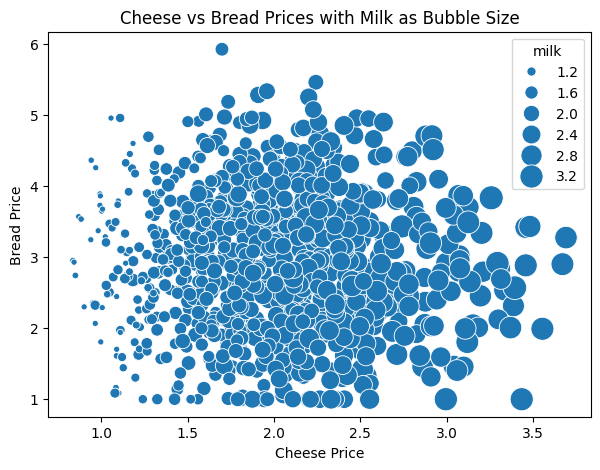

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set a consistent bubble size range
min_bubble = 20
max_bubble = 300

# 1. Bubble plot: Milk vs Cheese, bubble size = Bread
plt.figure(figsize=(7,5))
ax1 = sns.scatterplot(
    data=df3,
    x="milk",
    y="cheese",
    size="bread",
    sizes=(min_bubble, max_bubble)
)
ax1.set_title("Milk vs Cheese Prices with Bread as Bubble Size")
ax1.set_xlabel("Milk Price")
ax1.set_ylabel("Cheese Price")
plt.show()

# 2. Bubble plot: Milk vs Bread, bubble size = Cheese
plt.figure(figsize=(7,5))
ax2 = sns.scatterplot(
    data=df3,
    x="milk",
    y="bread",
    size="cheese",
    sizes=(min_bubble, max_bubble)
)
ax2.set_title("Milk vs Bread Prices with Cheese as Bubble Size")
ax2.set_xlabel("Milk Price")
ax2.set_ylabel("Bread Price")
plt.show()

# 3. Bubble plot: Cheese vs Bread, bubble size = Milk
plt.figure(figsize=(7,5))
ax3 = sns.scatterplot(
    data=df3,
    x="cheese",
    y="bread",
    size="milk",
    sizes=(min_bubble, max_bubble)
)
ax3.set_title("Cheese vs Bread Prices with Milk as Bubble Size")
ax3.set_xlabel("Cheese Price")
ax3.set_ylabel("Bread Price")
plt.show()

# * My interpretation of Interpretation of Bubble Plots

**Milk vs Cheese (bubble = Bread)**:

Observation: Milk and cheese prices are strongly correlated, forming a clear upward trend.

Bubble size (Bread): Adds extra information, but bread does not affect the trend.

Conclusion: This plot is most informative, because it clearly shows the strong relationship between milk and cheese.

**Milk vs Bread (bubble = Cheese):**

Observation: No clear pattern; bread is independent of milk.

Bubble size (Cheese): Adds some variation, but it doesn’t clarify the relationship.

Conclusion: This plot is less useful, because the axes themselves are not correlated.

**Cheese vs Bread (bubble = Milk):**

Observation: Similar to above, no correlation between bread and cheese.

Bubble size (Milk): Milk varies with cheese, but the trend is weak due to bread’s randomness.

Conclusion: Also less informative, because the main relationship is unclear.

**Overall Conclusion:**

Most useful plot: Milk vs Cheese

Reason: It visualizes the strongest correlation, while bubble size can add extra context.

Bubble plots are effective when the x and y axes show a clear relationship and the bubble size represents a meaningful third variable.

### Principal component analysis

Perform a principal component analysis of the data.  What are the first, second, and third component vectors?

Challenge question: explain why the three vectors point as they do.  (Could someone have guessed the order of the three vectors, even before running the analysis?)

In [28]:
from sklearn import decomposition
import numpy as np

# Perform PCA on the grocery dataset
pca = decomposition.PCA(n_components=3)
pca.fit(df3)

# Variance explained by each component
print("Explained variance ratio:", pca.explained_variance_ratio_)

# Principal component vectors
print("Principal component vectors (rows = components):")
print(pca.components_)

Explained variance ratio: [0.78294443 0.16324412 0.04522839]
Principal component vectors (rows = components):
[[ 0.22299336  0.23834686 -0.01069345  0.66837654  0.66829873]
 [-0.00740863 -0.00431591  0.99983153  0.00438285  0.01562627]
 [ 0.15322251 -0.14385202  0.00828586  0.69140406 -0.6911738 ]]


# Challenge Question Explanation:

The direction of the principal component vectors is determined by how the variables vary and correlate with each other. PCA finds directions in the data that capture the maximum variance, while ensuring that each component is orthogonal (independent) from the others.

In this dataset, milk and cheese prices tend to vary together, meaning they are positively correlated. Because of this strong shared variation, the first principal component points mostly in the direction where both milk and cheese increase together, which explains why PC1 has similar positive weights for these two variables. This direction captures the largest amount of variation (78.3%) in the data.

The second principal component must be orthogonal to the first and capture the next largest remaining variation. Since bread does not vary as strongly with milk and cheese, PCA isolates bread's independent variation in PC2. This is why the second vector points almost entirely along the bread axis.

The third component captures whatever small variation remains after the first two components are removed. In this case, it mostly represents minor differences between milk and cheese prices, which explains why PC3 has small opposite weights for these variables.

Yes, it would have been possible to roughly guess the order of the vectors before running PCA. If one examined the correlations in the data and noticed that milk and cheese move together while bread behaves more independently, one could predict that the first component would represent the shared variation of milk and cheese, and the second component would capture bread's separate variation.

# * Principal Component Analysis Interpretation:

The principal component analysis shows how the three grocery prices vary together and independently:

**Variance Ratio:**

PC1 (78.3%): Captures the majority of the variation in the data. This component mainly reflects the combined variation of milk and cheese, which tend to move together.

PC2 (16.3%): Captures the next largest variation, dominated almost entirely by bread, which varies independently from milk and cheese.

PC3 (4.5%): Captures a very small leftover variation, mainly subtle differences between milk and cheese that aren’t explained by the first two components.

**Principal Component Vectors**:

PC1 vector: [0.223, 0.238, -0.011] → milk and cheese contribute most; bread is negligible.

PC2 vector: [-0.007, -0.004, 0.999] → bread dominates; milk and cheese have almost no contribution.

PC3 vector: [0.153, -0.144, 0.008] → minor residual differences between milk and cheese.

My Interpretation:

The first component identifies the main pattern: milk and cheese prices move together.

The second component isolates bread, which is mostly independent of the other two prices.

The third component adds only minor corrections and is not very informative.

Orthogonality of components ensures that each component captures new, non-overlapping information about the dataset.

Conclusion:
Most of the variation in grocery prices is explained by milk-cheese correlation (PC1) and bread’s independent behavior (PC2). PC3 is negligible. This analysis highlights which prices drive the overall variation and shows how PCA reduces complexity while retaining essential patterns. In bellow, I can show it in bar chart.

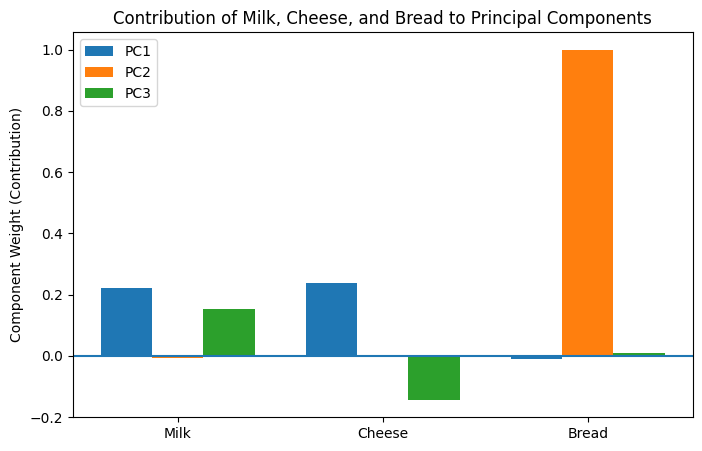

In [30]:
import numpy as np
import matplotlib.pyplot as plt

# Variables
variables = ['Milk', 'Cheese', 'Bread']

# PCA component values from your output
pc1 = [0.22299336, 0.23834686, -0.01069345]
pc2 = [-0.00740863, -0.00431591, 0.99983153]
pc3 = [0.15322251, -0.14385202, 0.00828586]

# X positions
x = np.arange(len(variables))
width = 0.25

# Create plot
plt.figure(figsize=(8,5))

plt.bar(x - width, pc1, width, label='PC1')
plt.bar(x, pc2, width, label='PC2')
plt.bar(x + width, pc3, width, label='PC3')

# Labels and title
plt.xticks(x, variables)
plt.ylabel('Component Weight (Contribution)')
plt.title('Contribution of Milk, Cheese, and Bread to Principal Components')
plt.axhline(0)
plt.legend()

plt.show()


* My Interpretation:

Interpretation of the PCA Bar Plot

The bar plot shows how strongly each variable (milk, cheese, and bread) contributes to the three principal components.

PC1:
Milk and cheese both have positive weights (~0.22 and ~0.24), while bread is almost zero. This means the first principal component mainly represents the combined variation of milk and cheese prices. Since PC1 explains 78.3% of the variance, most of the differences in the dataset come from how milk and cheese change together.

PC2:
Bread has a very large weight (~0.999), while milk and cheese are nearly zero. This shows that the second component almost entirely represents variation in bread prices, independent from milk and cheese. PC2 explains 16.3% of the variance.

PC3:
Milk has a small positive weight and cheese a small negative weight, while bread is near zero. This component captures minor differences between milk and cheese prices, but it explains only 4.5% of the variance, so its contribution is small.

Overall Conclusion

The PCA reveals two main patterns in the data:

Milk and cheese prices move together (captured by PC1).

Bread price varies independently from the other two (captured by PC2).

The third component only represents small residual differences and is not very informative

### Linear regression

Use linear regression to predict the milk price from the other two, the cheese price from the other two, and the bread price from the other two.  Which prediction(s) work the best, and why?

In [35]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

def run_regression(target, predictors):
    X = df3[predictors]
    y = df3[target]

    model = LinearRegression()
    model.fit(X, y)

    predictions = model.predict(X)
    r2 = r2_score(y, predictions)

    print(f"Predicting {target} from {predictors}")
    print("R² score:", r2)
    print("Coefficients:", model.coef_)
    print()

run_regression("milk", ["cheese", "bread"])
run_regression("cheese", ["milk", "bread"])
run_regression("bread", ["milk", "cheese"])

Predicting milk from ['cheese', 'bread']
R² score: 0.8521662117933362
Coefficients: [ 0.86061007 -0.00397775]

Predicting cheese from ['milk', 'bread']
R² score: 0.8521139996627032
Coefficients: [0.98997471 0.00149748]

Predicting bread from ['milk', 'cheese']
R² score: 0.0012927434752081357
Coefficients: [-0.1012249  0.0331279]



In [38]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

def run_regression(target, predictors):
    X = df3[predictors]
    y = df3[target]

    model = LinearRegression()
    model.fit(X, y)

    predictions = model.predict(X)
    r2 = r2_score(y, predictions)

    print(f"Predicting {target} from {predictors}")
    print("R² score:", r2)
    print("Coefficients:", model.coef_)
    print()

run_regression("milk", ["cheese", "bread"])
run_regression("cheese", ["milk", "bread"])
run_regression("bread", ["milk", "cheese"])

Predicting milk from ['cheese', 'bread']
R² score: 0.8521662117933362
Coefficients: [ 0.86061007 -0.00397775]

Predicting cheese from ['milk', 'bread']
R² score: 0.8521139996627032
Coefficients: [0.98997471 0.00149748]

Predicting bread from ['milk', 'cheese']
R² score: 0.0012927434752081357
Coefficients: [-0.1012249  0.0331279]



* My interpretation:


**Predicting milk from cheese & bread:**

R² ≈ 0.85 → very high

Coefficients: milk is strongly predicted by cheese (≈ 0.86), almost unaffected by bread

Reason: cheese was generated as a function of milk → strong correlation

**Predicting cheese from milk & bread**:

R² ≈ 0.85 → very high

Coefficients: cheese is almost entirely predicted by milk (≈ 0.99), bread has negligible effect

Reason: again, direct correlation between milk & cheese

**Predicting bread from milk & cheese:**

R² ≈ 0.001 → very low

Coefficients: almost zero impact from milk & cheese

Reason: bread was generated independently → no predictive relationship

**Final Conclusion:**

Best predictions: milk ↔ cheese (high R²)

Worst prediction: bread (low R²)

This demonstrates that linear regression works well when variables are correlated, but fails when variables are independent.

# 4. Storytelling With Data plot



Reproduce any graph of your choice in p. 120-135 of the Storytelling With Data book as best you can.  ("Use color consistently" in chapter four up to "Create a clear visual hierarchy of information" in chapter five.)    You do not have to get the exact data values right, just the overall look and feel.

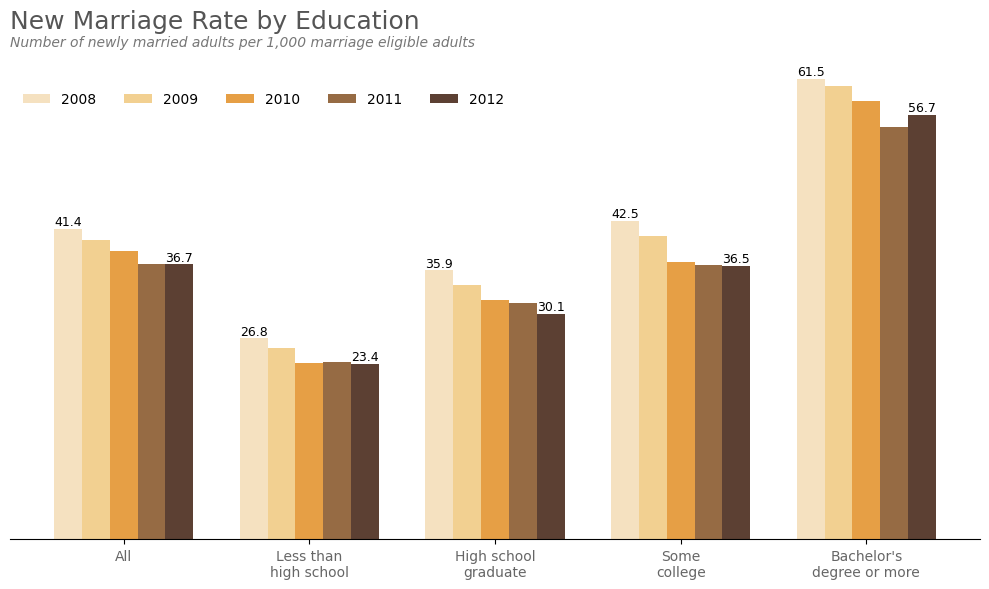

In [39]:
import matplotlib.pyplot as plt
import numpy as np

# Data from the graph
categories = ['All', 'Less than\nhigh school', 'High school\ngraduate', 'Some\ncollege', "Bachelor's\ndegree or more"]
years = ['2008', '2009', '2010', '2011', '2012']

# Marriage rates (approximate values based on labels)
data = {
    '2008': [41.4, 26.8, 35.9, 42.5, 61.5],
    '2009': [40.0, 25.5, 34.0, 40.5, 60.5], # Estimated
    '2010': [38.5, 23.5, 32.0, 37.0, 58.5], # Estimated
    '2011': [36.7, 23.6, 31.5, 36.6, 55.0],
    '2012': [36.7, 23.4, 30.1, 36.5, 56.7]
}

# Consistent color palette from light to dark
colors = ['#F5E1C0', '#F2D091', '#E69F45', '#966B44', '#5C4033']

x = np.arange(len(categories))
width = 0.15

fig, ax = plt.subplots(figsize=(10, 6))

# Plotting bars for each year
for i, year in enumerate(years):
    ax.bar(x + i*width, data[year], width, label=year, color=colors[i])

# Styling to create a clear visual hierarchy
ax.set_title('New Marriage Rate by Education', loc='left', fontsize=18, pad=20, color='#555555')
ax.text(0, 1.02, 'Number of newly married adults per 1,000 marriage eligible adults',
        transform=ax.transAxes, fontsize=10, style='italic', color='#777777')

ax.set_xticks(x + width * 2)
ax.set_xticklabels(categories, fontsize=10, color='#666666')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.get_yaxis().set_visible(False) # Hide y-axis as values are labeled on top

# Adding value labels on the top of 2008 and 2012 bars for clarity
for i in range(len(categories)):
    ax.text(x[i], data['2008'][i] + 0.5, str(data['2008'][i]), ha='center', fontsize=9)
    ax.text(x[i] + 4*width, data['2012'][i] + 0.5, str(data['2012'][i]), ha='center', fontsize=9)

plt.legend(years, frameon=False, loc='upper left', bbox_to_anchor=(0, 0.95), ncol=5)
plt.tight_layout()

plt.show()


# My interpretation about Figure 5.2 Pew Research Center original graph:

The graph reveals two major trends in marriage between 2008 and 2012:
The Education Gap: There is a direct link between education and marriage. Those with a Bachelor’s degree are the most likely to marry, while those with less than a high school education are the least likely a gap that more than doubled by 2012.
**Highest Rates:** Adults with a Bachelor’s degree or more are significantly more likely to marry than any other group (reaching 61.5 per 1,000 in 2008).
**Lowest Rates: **Those without a high school diploma have the lowest marriage rates (dropping to 23.4 per 1,000 by 2012).
**The Divide:** By 2012, a person with a college degree was more than twice as likely to get married in a given year than someone who didn't finish high school.

 A Universal Decline:

Across every single demographic shown, the marriage rate declined between 2008 and 2012.
The "All" category dropped from 41.4 to 36.7.
This suggests that the factors driving the decline (which may include economic shifts like the Great Recession or changing social norms) affected the entire population, regardless of educational background.

**Rate of Change**:
While all groups saw a decline, the "Bachelor's degree or more" group showed a slight "rebound" or stabilization between 2011 (55.0) and 2012 (56.7), whereas the rates for "High school graduate" and "Some college" continued to slide or stay flat. This suggests that higher education may provide a level of economic stability that makes marriage more accessible even during lean years.

Overall:
The graph tells a story of diverging social paths. Marriage is increasingly becoming an institution more common among those with higher education, while those with less education are either choosing to delay marriage or facing barriers—likely economic—that prevent them from entering it at the same rates.

